In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("PySpark-Colab") \
    .getOrCreate()

In [ ]:
spark.conf.set("spark.sql.caseSensitive", "true")

meta_df = (
    spark.read
    .option("multiLine", "false")
    .json("/content/drive/MyDrive/amazon dataset/Fashion_meta.jsonl")
)

display(meta_df)


DataFrame[average_rating: double, bought_together: string, categories: array<string>, description: array<string>, details: struct<ABPA Partslink Number:string,ASTM Fluid Rating:string,Active Ingredients:string,Age Range (Description):string,Age Range Description:string,Alarm Clock:string,Arch Type:string,Are Batteries Included:string,Assembled Depth:string,Assembled Height:string,Assembled Length:string,Assembled Width:string,Assembly Required:string,Auto Part Position:string,Auto Shutoff:string,Back Material Type:string,Back Style:string,Band Color:string,Band Length:string,Band Material Type:string,Band Size:string,Band Width:string,Base Type:string,Batteries:string,Batteries Included?:string,Batteries Required?:string,Battery Capacity:string,Battery Cell Composition:string,Battery Cell Type:string,Battery Description:string,Belt Style:string,Best Sellers Rank:struct<Climate Pledge Friendly: Apparel:bigint,Our Brands:bigint,Women's Activewear Leggings:bigint,Women's Activewear T-Shir

In [ ]:
meta_df.head(5)

[Row(average_rating=4.6, bought_together=None, categories=[], description=[], details=Row(ABPA Partslink Number=None, ASTM Fluid Rating=None, Active Ingredients=None, Age Range (Description)=None, Age Range Description=None, Alarm Clock=None, Arch Type=None, Are Batteries Included=None, Assembled Depth=None, Assembled Height=None, Assembled Length=None, Assembled Width=None, Assembly Required=None, Auto Part Position=None, Auto Shutoff=None, Back Material Type=None, Back Style=None, Band Color=None, Band Length=None, Band Material Type=None, Band Size=None, Band Width=None, Base Type=None, Batteries=None, Batteries Included?=None, Batteries Required?=None, Battery Capacity=None, Battery Cell Composition=None, Battery Cell Type=None, Battery Description=None, Belt Style=None, Best Sellers Rank=None, Bike Type=None, Binding=None, Biometric Security Feature=None, Blade Edge=None, Blade Length=None, Blade Material=None, Blade Shape=None, Blanket Form=None, Body Shape=None, Brake Style=None

In [ ]:
meta_df.printSchema()

root
 |-- average_rating: double (nullable = true)
 |-- bought_together: string (nullable = true)
 |-- categories: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- description: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- details: struct (nullable = true)
 |    |-- ABPA Partslink Number: string (nullable = true)
 |    |-- ASTM Fluid Rating: string (nullable = true)
 |    |-- Active Ingredients: string (nullable = true)
 |    |-- Age Range (Description): string (nullable = true)
 |    |-- Age Range Description: string (nullable = true)
 |    |-- Alarm Clock: string (nullable = true)
 |    |-- Arch Type: string (nullable = true)
 |    |-- Are Batteries Included: string (nullable = true)
 |    |-- Assembled Depth: string (nullable = true)
 |    |-- Assembled Height: string (nullable = true)
 |    |-- Assembled Length: string (nullable = true)
 |    |-- Assembled Width: string (nullable = true)
 |    |-- Assembly Required: string 

In [ ]:
len(meta_df.schema["details"].dataType)

474

In [ ]:
meta_df.columns

['average_rating',
 'bought_together',
 'categories',
 'description',
 'details',
 'features',
 'main_category',
 'parent_asin',
 'price',
 'rating_number',
 'store',
 'title',
 'year']

In [ ]:
from pyspark.sql.functions import col, count, when

meta_df.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in meta_df.columns
]).show(truncate=False)


+--------------+---------------+----------+-----------+-------+--------+-------------+-----------+------+-------------+-----+-----+----+
|average_rating|bought_together|categories|description|details|features|main_category|parent_asin|price |rating_number|store|title|year|
+--------------+---------------+----------+-----------+-------+--------+-------------+-----------+------+-------------+-----+-----+----+
|0             |757301         |0         |0          |0      |0       |0            |0          |714741|0            |23434|0    |0   |
+--------------+---------------+----------+-----------+-------+--------+-------------+-----------+------+-------------+-----+-----+----+



In [ ]:
numeric_cols = ["average_rating", "price", "rating_number", "year"]
meta_df.select(numeric_cols).describe().show()


+-------+------------------+------------------+------------------+------------------+
|summary|    average_rating|             price|     rating_number|              year|
+-------+------------------+------------------+------------------+------------------+
|  count|            757301|             42560|            757301|            757301|
|   mean|3.9021546254392994| 40.35850939849368|18.036566702011484|2018.5185679142112|
| stddev|0.9827831073397905|140.78435413170106| 224.8077155552886|1.8870111241853387|
|    min|               1.0|              0.01|                 1|            2015.0|
|    max|               5.0|           12111.5|             46299|            2023.0|
+-------+------------------+------------------+------------------+------------------+



In [ ]:
meta_df.groupBy("main_category") \
       .count() \
       .orderBy(col("count").desc()) \
       .show(10, truncate=False)


+--------------+------+
|main_category |count |
+--------------+------+
|AMAZON FASHION|757301|
+--------------+------+



In [ ]:
meta_df.groupBy("store") \
       .count() \
       .orderBy(col("count").desc()) \
       .show(10, truncate=False)


+-----------+-----+
|store      |count|
+-----------+-----+
|NULL       |23434|
|Nike       |4326 |
|Romwe      |3968 |
|GRACE KARIN|3691 |
|Verdusa    |3600 |
|Floerns    |3292 |
|SheIn      |2952 |
|Ekouaer    |2666 |
|Disney     |2584 |
|SweatyRocks|2555 |
+-----------+-----+
only showing top 10 rows


In [ ]:
from pyspark.sql.functions import explode

meta_df.select(explode("categories").alias("category")) \
       .groupBy("category") \
       .count() \
       .orderBy(col("count").desc()) \
       .show(10, truncate=False)


+--------+-----+
|category|count|
+--------+-----+
+--------+-----+



In [ ]:
meta_df.select(explode("features").alias("feature")) \
       .groupBy("feature") \
       .count() \
       .orderBy(col("count").desc()) \
       .show(10, truncate=False)


+------------------+-----+
|feature           |count|
+------------------+-----+
|Pull On closure   |97521|
|Hand Wash Only    |78624|
|Machine Wash      |65993|
|Button closure    |30943|
|Zipper closure    |29567|
|100% Cotton       |23015|
|Drawstring closure|19786|
|100% Polyester    |18608|
|Rubber sole       |14407|
|Imported          |12994|
+------------------+-----+
only showing top 10 rows


In [ ]:
from pyspark.sql.functions import size

meta_df.select(size("description").alias("desc_length")) \
       .describe() \
       .show()


+-------+------------------+
|summary|       desc_length|
+-------+------------------+
|  count|            757301|
|   mean|0.1657623586922505|
| stddev|1.3683031192334982|
|    min|                 0|
|    max|               101|
+-------+------------------+



In [ ]:
meta_df.withColumn("category", explode("categories")) \
       .groupBy("category") \
       .agg(
           {"average_rating": "avg", "rating_number": "sum"}
       ) \
       .orderBy(col("avg(average_rating)").desc()) \
       .show(10, truncate=False)


+--------+------------------+-------------------+
|category|sum(rating_number)|avg(average_rating)|
+--------+------------------+-------------------+
+--------+------------------+-------------------+



In [ ]:
meta_df.select("price").describe().show()


+-------+------------------+
|summary|             price|
+-------+------------------+
|  count|             42560|
|   mean| 40.35850939849368|
| stddev|140.78435413170106|
|    min|              0.01|
|    max|           12111.5|
+-------+------------------+



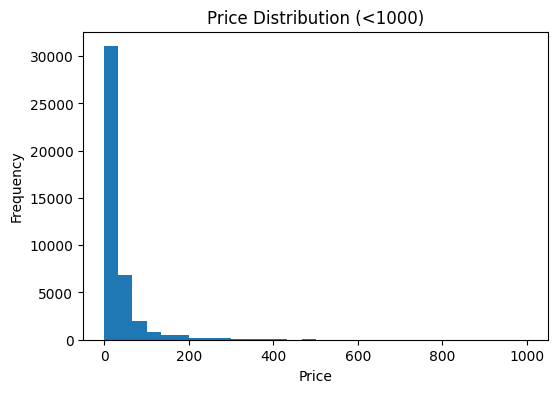

In [ ]:
price_pdf = meta_df.select("price") \
                   .dropna() \
                   .filter(col("price") < 1000) \
                   .toPandas()

plt.figure(figsize=(6,4))
plt.hist(price_pdf["price"], bins=30)
plt.title("Price Distribution (<1000)")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()


In [ ]:
meta_df.select("price", "average_rating") \
       .filter(col("price").isNotNull()) \
       .groupBy("average_rating") \
       .avg("price") \
       .show()


+--------------+------------------+
|average_rating|        avg(price)|
+--------------+------------------+
|           2.4| 29.66596153846154|
|           3.5|  31.4103871681415|
|           2.9|29.214228187919428|
|           3.7| 32.57752252252242|
|           4.5| 34.24342582315974|
|           1.4|28.419444444444444|
|           1.7| 41.23769230769231|
|           2.3|32.085974025974025|
|           3.4|27.458377622377537|
|           4.9|43.819467213114685|
|           2.5| 32.31970238095239|
|           1.0| 41.18483400809708|
|           3.1| 35.38781637717116|
|           2.7| 35.47534031413611|
|           4.1|31.379940152339586|
|           2.2| 28.64358208955224|
|           2.8|38.979612068965494|
|           4.0|39.576941391941595|
|           1.9|24.740606060606062|
|           3.9| 31.97722300140254|
+--------------+------------------+
only showing top 20 rows


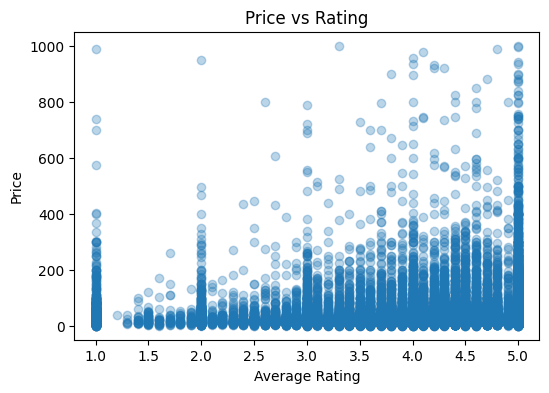

In [ ]:
pr_pdf = meta_df.select("price", "average_rating") \
                .dropna() \
                .filter(col("price") < 1000) \
                .toPandas()

plt.figure(figsize=(6,4))
plt.scatter(pr_pdf["average_rating"], pr_pdf["price"], alpha=0.3)
plt.xlabel("Average Rating")
plt.ylabel("Price")
plt.title("Price vs Rating")
plt.show()


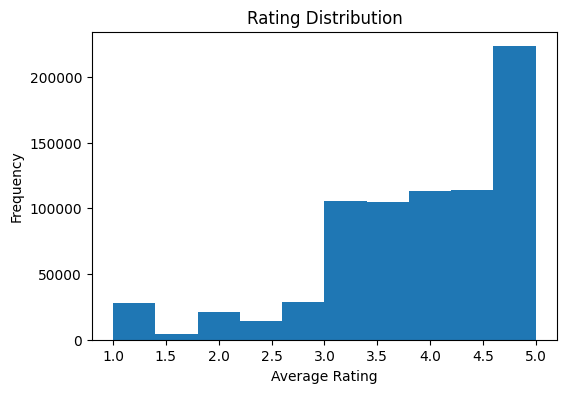

In [ ]:
rating_pdf = meta_df.select("average_rating") \
                    .dropna() \
                    .toPandas()

plt.figure(figsize=(6,4))
plt.hist(rating_pdf["average_rating"], bins=10)
plt.title("Rating Distribution")
plt.xlabel("Average Rating")
plt.ylabel("Frequency")
plt.show()


In [ ]:
meta_df.groupBy("year") \
       .count() \
       .orderBy("year") \
       .show()


+------+------+
|  year| count|
+------+------+
|2015.0| 28019|
|2016.0| 98057|
|2017.0|131222|
|2018.0|126644|
|2019.0|129737|
|2020.0| 96206|
|2021.0|110392|
|2022.0| 34340|
|2023.0|  2684|
+------+------+



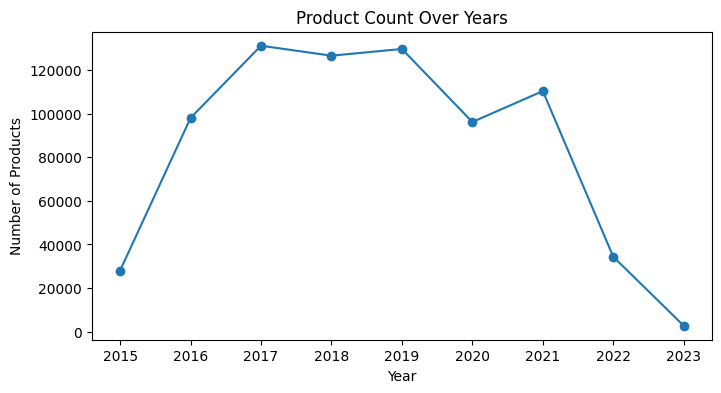

In [ ]:
year_df = meta_df.groupBy("year") \
                 .count() \
                 .orderBy("year")

year_pdf = year_df.toPandas()

plt.figure(figsize=(8,4))
plt.plot(year_pdf["year"], year_pdf["count"], marker="o")
plt.title("Product Count Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Products")
plt.show()


In [ ]:
meta_df.select(
    count(when(col("details").isNotNull(), 1)).alias("details_present")
).show()


+---------------+
|details_present|
+---------------+
|         757301|
+---------------+



In [ ]:
meta_df.select(
    col("details.Brand").alias("brand"),
    col("details.Manufacturer").alias("manufacturer")
).groupBy("brand") \
 .count() \
 .orderBy(col("count").desc()) \
 .show(10, truncate=False)


+-------------+------+
|brand        |count |
+-------------+------+
|NULL         |719902|
|Generic      |174   |
|Bioworld     |105   |
|Nike         |102   |
|Doomfist     |100   |
|Hicarer      |92    |
|G-Ahora      |85    |
|Travelambo   |84    |
|Jude Jewelers|83    |
|Alex and Ani |83    |
+-------------+------+
only showing top 10 rows


In [ ]:
from pyspark.sql.functions import col

meta_df.filter(col("store").isNotNull()).count()


733867

In [ ]:
meta_df.filter(col("store").isNotNull()) \
       .select("store") \
       .distinct() \
       .show(20, truncate=False)


+-------------------+
|store              |
+-------------------+
|ACEVOG             |
|Latuza             |
|JDKBJAM            |
|Kkseuza            |
|Hicarer            |
|ChainsPro          |
|Xineppu            |
|Yoaresweet         |
|Xelement           |
|SySea              |
|TUIJI              |
|HUNTER             |
|LemonGirl          |
|Fighting to Achieve|
|BONSHINY           |
|Fedi Apparel       |
|BraNurY            |
|ANNA               |
|Dcoolone           |
|HATSANDSCARF       |
+-------------------+
only showing top 20 rows


In [ ]:
from pyspark.sql.functions import trim, lower

clean_meta_df = meta_df \
    .filter(col("store").isNotNull()) \
    .filter(trim(col("store")) != "") \
    .filter(lower(col("store")) != "null")


In [ ]:
store_df = clean_meta_df \
    .groupBy("store") \
    .count() \
    .orderBy(col("count").desc()) \
    .limit(10)

store_df.show(truncate=False)


+-----------+-----+
|store      |count|
+-----------+-----+
|Nike       |4326 |
|Romwe      |3968 |
|GRACE KARIN|3691 |
|Verdusa    |3600 |
|Floerns    |3292 |
|SheIn      |2952 |
|Ekouaer    |2666 |
|Disney     |2584 |
|SweatyRocks|2555 |
|Milumia    |2103 |
+-----------+-----+



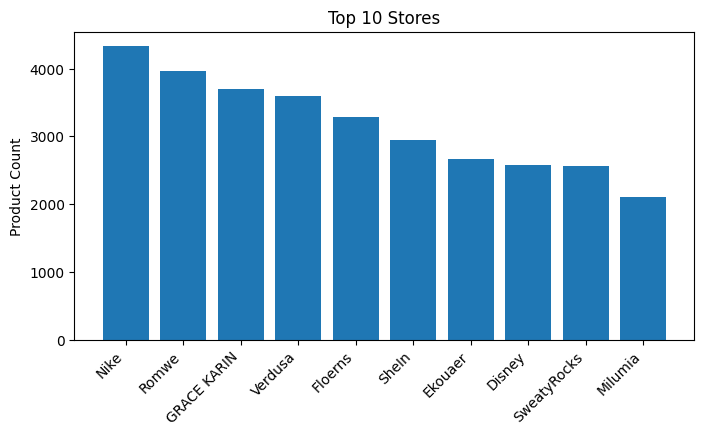

In [ ]:
from pyspark.sql.functions import explode,col
import matplotlib.pyplot as plt
store_df = clean_meta_df.groupBy("store") \
                  .count() \
                  .orderBy(col("count").desc()) \
                  .limit(10)

store_pdf = store_df.toPandas()

plt.figure(figsize=(8,4))
plt.bar(store_pdf["store"], store_pdf["count"])
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 Stores")
plt.ylabel("Product Count")
plt.show()


In [ ]:
meta_df.groupBy("parent_asin") \
       .count() \
       .filter(col("count") > 1) \
       .show()


+-----------+-----+
|parent_asin|count|
+-----------+-----+
+-----------+-----+



In [ ]:
meta_df.filter(
    col("price").isNull() & (col("average_rating") >= 4)
).show(5)


+--------------+---------------+----------+-----------+--------------------+--------------------+--------------+-----------+-----+-------------+------------------+--------------------+------+
|average_rating|bought_together|categories|description|             details|            features| main_category|parent_asin|price|rating_number|             store|               title|  year|
+--------------+---------------+----------+-----------+--------------------+--------------------+--------------+-----------+-----+-------------+------------------+--------------------+------+
|           4.6|           NULL|        []|         []|{NULL, NULL, NULL...|                  []|AMAZON FASHION| B08BHN9PK5| NULL|           16|          GiveGift|YUEDGE 5 Pairs Me...|2021.0|
|           4.1|           NULL|        []|         []|{NULL, NULL, NULL...|[Drawstring closu...|AMAZON FASHION| B08R39MRDW| NULL|            7|            DouBCQ|DouBCQ Women's Pa...|2021.0|
|           4.3|           NULL|        

insights

-Frequency of products with high rating(4-5) is high.
-Most products are low priced
-Outliers are present
-Expensive products do not necessarily receive higher ratings.
-Product availability grew rapidly until 2019 and declined significantly in recent years.
-Nike is store with highest